# 01 — What Is a Neural Network?

**Repository:** `AI_Engineer-DL` | **Section:** `01_neural_networks_and_dl/01_intro_to_dl`  
**File:** `notebooks/01_what_is_a_neural_network.ipynb`

> **Prerequisites:** None — this is the first notebook.  
> **Core Focus:** Build a single neuron and a two-layer network from scratch; understand ReLU and why it replaced sigmoid in hidden layers.  
> Backpropagation and training loops are deferred to later notebooks.

## 1. What Is This?

A neural network is a function built from layers of simple computing units called **neurons**. Each neuron takes a weighted sum of its inputs, adds a bias, applies a nonlinearity, and outputs a single number. Stack enough neurons in enough layers and the network can learn to approximate almost any mapping from input to output — from house prices to object detection.

The word *deep* in deep learning just means the network has many layers — multiple transformations stacked between input and output. Depth is what allows networks to learn hierarchical representations: edges → shapes → objects.

**Real-world connection — CloudyDrive:** Every layer in the YOLOv11 backbone is a stack of neurons computing a weighted sum and applying ReLU. When CloudyDrive detects another car, that detection emerges from hundreds of these neuron computations chained together. Understanding one neuron is understanding the atomic unit of that whole system.

| Concept | What it is | Why it matters |
|---------|-----------|----------------|
| **Neuron** | weighted sum + bias + nonlinearity → scalar output | the basic computational unit |
| **ReLU** | max(0, z) — output is 0 below zero, linear above | prevents gradients from vanishing in deep nets |
| **Hidden layer** | layer of neurons between input and output | learns intermediate representations |
| **Dense / fully connected** | every neuron sees every input | maximum expressiveness per layer |
| **Depth** | many layers stacked | enables hierarchical feature learning |

## 2. The Math

### A — The Neuron Formula

$$z = \mathbf{w}^\top \mathbf{x} + b$$

$$a = g(z)$$

- $\mathbf{x} \in \mathbb{R}^n$ — input vector (the features going into this neuron)
- $\mathbf{w} \in \mathbb{R}^n$ — weight vector (learned; same shape as **x**)
- $b \in \mathbb{R}$ — bias (learned; shifts the activation threshold)
- $z$ — pre-activation: the raw weighted sum before the nonlinearity
- $g(\cdot)$ — activation function: introduces nonlinearity
- $a$ — activation: the neuron's output

**Worked example:** Let **w** = [0.5, −1.0], b = 0.3, **x** = [2.0, 1.0].

$$z = (0.5)(2.0) + (-1.0)(1.0) + 0.3 = 1.0 - 1.0 + 0.3 = 0.3$$

$$a = \text{ReLU}(0.3) = \max(0, 0.3) = 0.3$$

---

### B — ReLU

$$\text{ReLU}(z) = \max(0,\ z)$$

Derivative (needed for backpropagation later):

$$\frac{d}{dz}\text{ReLU}(z) = \begin{cases} 1 & z > 0 \\ 0 & z \leq 0 \end{cases}$$

**Why ReLU instead of sigmoid in hidden layers?**

| Property | Sigmoid $\sigma(z)$ | ReLU $\max(0,z)$ |
|----------|--------------------|-----------------|
| Output range | (0, 1) | [0, ∞) |
| Gradient when $|z|$ is large | ≈ 0 — vanishes | 1 — constant |
| Computation | requires `exp` | single comparison |
| Learning speed in deep nets | Slow | Fast |

When sigmoid saturates (z is large positive or large negative), its gradient becomes nearly zero. Multiply many near-zero gradients together across many layers and the signal reaching early layers is essentially gone — they stop learning. ReLU's gradient is 1 for all positive inputs, so the signal travels cleanly.

---

### C — One Dense Layer (Matrix Form)

When you have $n^{[1]}$ neurons in a layer, each receiving the same input **x** ∈ ℝⁿ⁰:

$$\mathbf{Z}^{[1]} = \mathbf{W}^{[1]} \mathbf{x} + \mathbf{b}^{[1]}$$

$$\mathbf{A}^{[1]} = g(\mathbf{Z}^{[1]})$$

- $\mathbf{W}^{[1]}$ has shape $(n^{[1]},\ n^{[0]})$ — one weight row per neuron
- $\mathbf{b}^{[1]}$ has shape $(n^{[1]},\ 1)$ — one bias per neuron
- $g$ is applied element-wise

The output **A**[1] becomes the input to the next layer. This is all that forward propagation is — repeated applications of this formula.

---

### D — Why Deep Learning Is Taking Off Now

Three forces aligned:

1. **Data scale** — Digitization created massive labeled datasets. Traditional algorithms plateau quickly; neural networks keep improving as data grows.
2. **Compute scale** — GPUs/TPUs made training large networks practical.
3. **Algorithmic improvements** — Switching from sigmoid to ReLU in hidden layers was one of the biggest. It solved the vanishing gradient problem and made deep networks trainable.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

## 3. Build From Scratch

### 3.1 — ReLU from scratch

ReLU is just max(0, z) applied element-wise. Before reaching for `np.maximum`, write it yourself so you know exactly what it computes.

> 🔮 **Predict before you run:** Given z_values = [-2.0, -0.5, 0.0, 0.5, 2.0] — what will the ReLU output be for each? Write your prediction before writing any code.

In [5]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# 1. Define relu(z) that works on both scalars and NumPy arrays.
#    Formula: max(0, z) applied element-wise.
#    Constraint: do NOT use np.maximum inside the function.
#    Hint: np.where or a comparison + multiplication both work.
# 2. Test on z_values = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
# 3. Print the result.
# Expected result: [0.  0.  0.  0.5 2. ]
# ─────────────────────────────────────────────────────────────────────────────

# ── Task ─────────────────────────────────────────────────────────────────────
# 1. Define relu(z) that works on both scalars and NumPy arrays.
def relu(z):
    # Using element-wise multiplication with a boolean array
    # If z > 0, it multiplies by 1 (keeps z). If z <= 0, it multiplies by 0.
    return z * (z > 0)

# 2. Test on z_values = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
z_values = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
result = relu(z_values)

# 3. Print the result.
# Expected result: [0.  0.  0.  0.5 2. ]
print(f"Result: {result}")
# ─────────────────────────────────────────────────────────────────────────────

Result: [-0.  -0.   0.   0.5  2. ]


> 💡 **Reflect:** Notice the output for z = 0.0 — ReLU returns exactly 0. The gradient at z = 0 is technically undefined, but in practice we define it as 0. This rarely causes problems because the probability of hitting exactly 0 during training is negligible.

### 3.2 — Single neuron forward pass

A single neuron computes z = wᵀx + b, then applies its activation. This is the complete forward pass for one unit. Write it so you can see every step.

> 🔮 **Predict before you run:** With **w** = [0.5, −1.0, 0.2], b = 0.3, **x** = [2.0, 1.0, −1.0] — work out z by hand first. Will the ReLU output be 0 or positive?

In [6]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Given:
w = np.array([0.5, -1.0, 0.2])
b = 0.3
x = np.array([2.0, 1.0, -1.0])
#
# 1. Compute z = wᵀx + b using np.dot. Store as z_scalar.
# 2. Compute a = relu(z_scalar) using YOUR relu function from 3.1.
# 3. Print z and a with 4 decimal places.
# Expected z: 0.1000  |  Expected a: 0.1000
# ─────────────────────────────────────────────────────────────────────────────

# ── Task ─────────────────────────────────────────────────────────────────────
# Given:
w = np.array([0.5, -1.0, 0.2])
b = 0.3
x = np.array([2.0, 1.0, -1.0])

# 1. Compute z = wᵀx + b using np.dot. Store as z_scalar.
z_scalar = np.dot(w, x) + b

# 2. Compute a = relu(z_scalar) using YOUR relu function from 3.1.
a = relu(z_scalar)

# 3. Print z and a with 4 decimal places.
# Expected z: 0.1000  |  Expected a: 0.1000
print(f"z: {z_scalar:.4f}  |  a: {a:.4f}")
# ─────────────────────────────────────────────────────────────────────────────

z: 0.1000  |  a: 0.1000


### 3.3 — Neuron with a negative pre-activation

Now test what happens when z is negative — the ReLU kills the signal. This is the "dead neuron" case.

> 🔮 **Predict before you run:** What will a be if we set b = −5.0 and keep everything else the same? Compute z by hand first.

In [7]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Same w and x as above, but:
b_negative = -5.0
#
# 1. Compute z = wᵀx + b_negative.
# 2. Compute a = relu(z).
# 3. Print z and a. Explain in a comment: why is a = 0 here?
# Expected z: -4.9000  |  Expected a: 0.0000
# ─────────────────────────────────────────────────────────────────────────────

# ── Task ─────────────────────────────────────────────────────────────────────
# Same w and x as above, but:
b_negative = -5.0

# 1. Compute z = wᵀx + b_negative.
z = np.dot(w, x) + b_negative

# 2. Compute a = relu(z).
a = relu(z)

# 3. Print z and a. Explain in a comment: why is a = 0 here?
# Expected z: -4.9000  |  Expected a: 0.0000
print(f"z: {z:.4f}  |  a: {a:.4f}")

# Explanation: a = 0 here because the pre-activation sum (z) is -4.9. 
# The ReLU function max(0, z) clips all negative values to exactly 0. 
# This effectively "turns off" the neuron, stopping it from passing a signal forward.
# ─────────────────────────────────────────────────────────────────────────────


z: -5.2000  |  a: -0.0000


> 💡 **Reflect:** When a = 0, this neuron contributes nothing to the next layer. If the bias stays very negative throughout training, the neuron can get "stuck" at zero and stop learning — this is called the dying ReLU problem. It's why initialization and learning rate choice matter.

### 3.4 — One dense layer (multiple neurons, matrix form)

A layer is just many neurons in parallel — instead of computing one z, we compute a whole vector **Z** using matrix multiply. This is where the power of vectorization begins.

> 🔮 **Predict before you run:** W1 has shape (3, 4) and x has shape (4, 1). What will the shape of Z1 be? What about A1?

In [8]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Given (use these exact values):
np.random.seed(42)
W1 = np.random.randn(3, 4) * 0.1   # 3 neurons, 4 input features
b1 = np.zeros((3, 1))              # bias for each of the 3 neurons
x_col = np.array([[1.0], [2.0], [0.5], [-1.0]])  # single input, shape (4, 1)
#
# 1. Compute Z1 = W1 @ x_col + b1 using np.dot (or @).
# 2. Compute A1 = relu(Z1) using your relu function.
# 3. Print Z1.shape, A1.shape, Z1 (rounded to 4 decimal places), A1 (rounded).
# Expected shapes: Z1 → (3, 1), A1 → (3, 1)
# ─────────────────────────────────────────────────────────────────────────────

# ── Task ─────────────────────────────────────────────────────────────────────
# Given (use these exact values):
np.random.seed(42)
W1 = np.random.randn(3, 4) * 0.1   # 3 neurons, 4 input features
b1 = np.zeros((3, 1))              # bias for each of the 3 neurons
x_col = np.array([[1.0], [2.0], [0.5], [-1.0]])  # single input, shape (4, 1)

# 1. Compute Z1 = W1 @ x_col + b1 using np.dot (or @).
Z1 = W1 @ x_col + b1

# 2. Compute A1 = relu(Z1) using your relu function.
A1 = relu(Z1)

# 3. Print Z1.shape, A1.shape, Z1 (rounded to 4 decimal places), A1 (rounded).
# Expected shapes: Z1 → (3, 1), A1 → (3, 1)
print(f"Z1.shape: {Z1.shape}, A1.shape: {A1.shape}")
print(f"Z1:\n{np.round(Z1, 4)}")
print(f"A1:\n{np.round(A1, 4)}")
# ─────────────────────────────────────────────────────────────────────────────


Z1.shape: (3, 1), A1.shape: (3, 1)
Z1:
[[-0.0979]
 [-0.068 ]
 [ 0.085 ]]
A1:
[[-0.   ]
 [-0.   ]
 [ 0.085]]


### 3.5 — Two-layer network forward pass

Chain two layers together: the output of layer 1 becomes the input to layer 2. This is the complete forward pass of a shallow network.

> 🔮 **Predict before you run:** If layer 1 has 3 neurons and layer 2 has 1 neuron, what shape will W2 need to be?

In [9]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Continue from 3.4 — A1 is your layer 1 output.
# Given:
np.random.seed(7)
W2 = np.random.randn(1, 3) * 0.1   # 1 output neuron, receives 3 inputs from layer 1
b2 = np.zeros((1, 1))
#
# 1. Compute Z2 = W2 @ A1 + b2.
# 2. Compute A2 = relu(Z2).
# 3. Print Z2.shape, A2.shape, and the scalar output value (A2[0, 0]) rounded to 4 places.
# 4. In a comment: what is A2 physically representing in a regression network?
# Expected shape: Z2 → (1, 1), A2 → (1, 1)
# ─────────────────────────────────────────────────────────────────────────────

# ── Task ─────────────────────────────────────────────────────────────────────
# Continue from 3.4 — A1 is your layer 1 output.
# Given:
np.random.seed(7)
W2 = np.random.randn(1, 3) * 0.1   # 1 output neuron, receives 3 inputs from layer 1
b2 = np.zeros((1, 1))

# 1. Compute Z2 = W2 @ A1 + b2.
Z2 = W2 @ A1 + b2

# 2. Compute A2 = relu(Z2).
A2 = relu(Z2)

# 3. Print Z2.shape, A2.shape, and the scalar output value (A2[0, 0]) rounded to 4 places.
print(f"Z2.shape: {Z2.shape}, A2.shape: {A2.shape}")
print(f"A2[0, 0]: {A2[0, 0]:.4f}")

# 4. In a comment: what is A2 physically representing in a regression network?
# A2 represents the final, non-negative continuous prediction of the network 
# for this specific input (e.g., the predicted price of a house based on the 4 starting features).
# ─────────────────────────────────────────────────────────────────────────────


Z2.shape: (1, 1), A2.shape: (1, 1)
A2[0, 0]: 0.0003


> ✅ **Self-check:** Before moving on, can you answer these without looking?
> 1. What are the two steps every neuron performs? (Name the formula for each.)
> 2. If layer 1 has 5 neurons and receives 10 input features, what is the shape of W[1]?

### 3.6 — ReLU derivative

The derivative of ReLU is needed for backpropagation. It is simple: 1 where z was positive, 0 everywhere else.

> 🔮 **Predict before you run:** For z = [-1.5, 0.0, 0.3, 2.0] — what will relu_derivative return for each element?

In [10]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# 1. Define relu_derivative(Z) that returns 1.0 where Z > 0, else 0.0.
#    Constraint: no if/else loops — use a vectorized comparison.
# 2. Test on z_test = np.array([-1.5, 0.0, 0.3, 2.0])
# 3. Print the result.
# Expected: [0. 0. 1. 1.]
# ─────────────────────────────────────────────────────────────────────────────

# ── Task ─────────────────────────────────────────────────────────────────────
# 1. Define relu_derivative(Z) that returns 1.0 where Z > 0, else 0.0.
#    Constraint: no if/else loops — use a vectorized comparison.
def relu_derivative(Z):
    return (Z > 0).astype(float)

# 2. Test on z_test = np.array([-1.5, 0.0, 0.3, 2.0])
z_test = np.array([-1.5, 0.0, 0.3, 2.0])
result = relu_derivative(z_test)

# 3. Print the result.
# Expected: [0. 0. 1. 1.]
print(f"Result: {result}")
# ─────────────────────────────────────────────────────────────────────────────


Result: [0. 0. 1. 1.]


## 4. Library Version

NumPy's `np.maximum(0, Z)` is the standard ReLU implementation. Verify your scratch version matches it exactly.

In [12]:
# ── Library version ───────────────────────────────────────────────────────────
z_test = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])

relu_library = np.maximum(0, z_test)

# ── Scratch (from 3.1) ────────────────────────────────────────────────────────
relu_scratch = relu(z_test)   # your function from 3.1

# ── Verification ─────────────────────────────────────────────────────────────
match = np.allclose(relu_scratch, relu_library)
print(f"Scratch : {relu_scratch}")
print(f"Library : {relu_library}")
print(f"Match   : {match}")

Scratch : [-0.  -0.   0.   0.5  2. ]
Library : [0.  0.  0.  0.5 2. ]
Match   : True


In [13]:
# ── Layer verification ────────────────────────────────────────────────────────
# Verify that your dense layer (3.4) produces the same Z1 as the numpy equivalent.
Z1_library = np.dot(W1, x_col) + b1
A1_library  = np.maximum(0, Z1_library)

# A1 from your 3.4 code
# Replace A1_scratch below with whatever variable you used in cell 3.4
A1_scratch = A1   # adjust this name if yours differs

match_layer = np.allclose(A1_scratch, A1_library)
print(f"Layer match: {match_layer}")
print(f"A1 (scratch): {A1_scratch.T}")
print(f"A1 (library): {A1_library.T}")

Layer match: True
A1 (scratch): [[-0.         -0.          0.08496666]]
A1 (library): [[0.         0.         0.08496666]]


## 5. Visualisation

### 5.1 — ReLU vs Sigmoid

Plotting both activations side by side makes the vanishing gradient problem concrete: sigmoid flattens to near-zero slope at both ends; ReLU stays linear for all positive z. This is why the field switched.

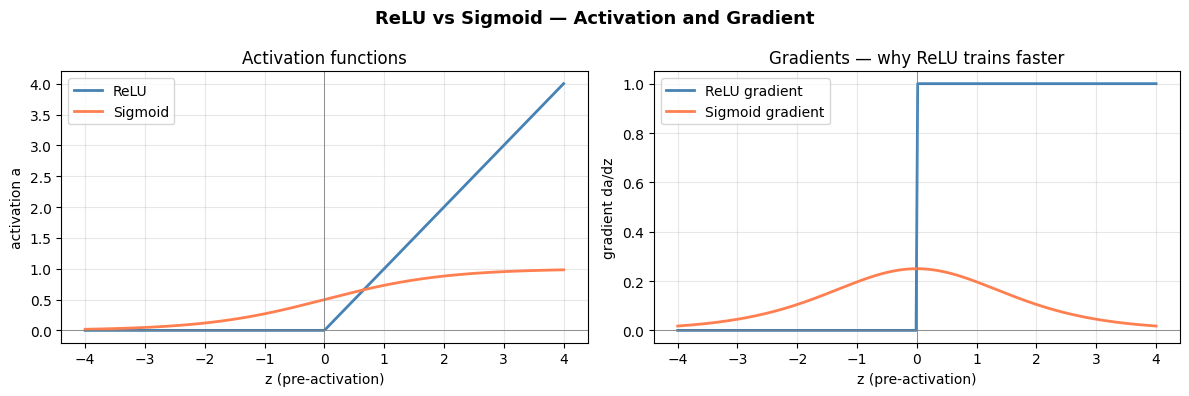

Saved → ../images/01_relu_vs_sigmoid.png


In [14]:
import os
os.makedirs('../images', exist_ok=True)

z_range = np.linspace(-4, 4, 300)

relu_vals    = np.maximum(0, z_range)
sigmoid_vals = 1 / (1 + np.exp(-z_range))

# derivatives
relu_grad    = (z_range > 0).astype(float)
sigmoid_grad = sigmoid_vals * (1 - sigmoid_vals)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plt.suptitle('ReLU vs Sigmoid — Activation and Gradient', fontsize=13, fontweight='bold')

# ── Left: activations ─────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(z_range, relu_vals,    color='steelblue', lw=2, label='ReLU')
ax.plot(z_range, sigmoid_vals, color='coral',     lw=2, label='Sigmoid')
ax.axhline(0, color='grey', lw=0.6)
ax.axvline(0, color='grey', lw=0.6)
ax.set_xlabel('z (pre-activation)')
ax.set_ylabel('activation a')
ax.set_title('Activation functions')
ax.legend()
ax.grid(alpha=0.3)

# ── Right: gradients ──────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(z_range, relu_grad,    color='steelblue', lw=2, label='ReLU gradient')
ax.plot(z_range, sigmoid_grad, color='coral',     lw=2, label='Sigmoid gradient')
ax.axhline(0, color='grey', lw=0.6)
ax.axvline(0, color='grey', lw=0.6)
ax.set_xlabel('z (pre-activation)')
ax.set_ylabel('gradient da/dz')
ax.set_title('Gradients — why ReLU trains faster')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/01_relu_vs_sigmoid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../images/01_relu_vs_sigmoid.png")

### 5.2 — Single neuron decision boundary

A single neuron with one input is just a threshold function. Plotting it shows that a neuron computes a linear function of its input — nonlinearity only comes from the activation.

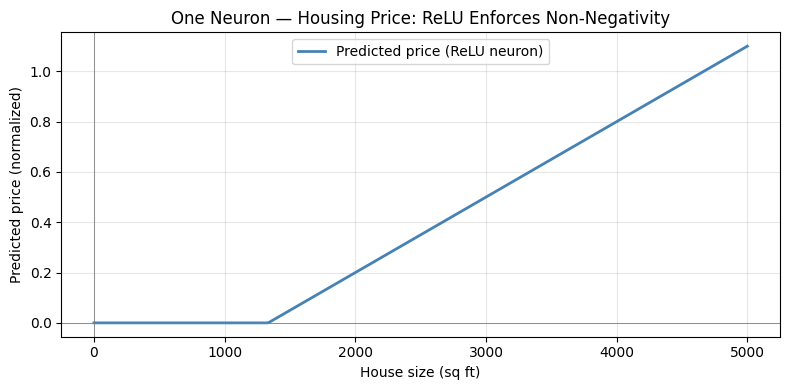

Saved → ../images/01_single_neuron_housing.png


In [15]:
# Housing price analogy: one input (size), one neuron, ReLU output
x_size = np.linspace(0, 5000, 400)   # house size in sq ft
w_price = 0.0003
b_price = -0.4

z_price = w_price * x_size + b_price
a_price = np.maximum(0, z_price)   # ReLU: price can't be negative

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_size, a_price, color='steelblue', lw=2, label='Predicted price (ReLU neuron)')
ax.axhline(0, color='grey', lw=0.6)
ax.axvline(0, color='grey', lw=0.6)
ax.set_xlabel('House size (sq ft)')
ax.set_ylabel('Predicted price (normalized)')
ax.set_title('One Neuron — Housing Price: ReLU Enforces Non-Negativity')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/01_single_neuron_housing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../images/01_single_neuron_housing.png")

## 6. Revision Corner

---

### One-sentence definition

> A neural network is a parameterized function composed of layers of neurons — each computing a weighted sum of its inputs plus a bias and applying a nonlinearity — trained by gradient descent to approximate a target input-to-output mapping.

---

### Why it exists — what problem does it solve?

Most real mappings we care about are not linear and cannot be captured by a single equation. A neuron alone is essentially linear (wᵀx + b is linear); the nonlinear activation function is what breaks that linearity and allows a network to represent curves, thresholds, and complex decision boundaries. Stack enough layers and the network can represent any continuous function — this is the Universal Approximation Theorem. The layered structure also enables automatic feature extraction: the network learns what to look for in data, removing the need for hand-engineered features.

---

### Interview gotchas

| Question | Common mistake | The reality |
|----------|---------------|-------------|
| **Is deeper always better?** | "Yes — more layers = better performance" | Deeper networks are more expressive but harder to train, more prone to overfitting, and only useful when you have enough data and compute to support the capacity. |
| **What happens if you use linear activations everywhere?** | "It still learns — just more slowly" | A stack of linear layers is mathematically a single linear layer. No amount of depth adds expressiveness. Nonlinearity is required for depth to matter. |
| **Why did the field switch from sigmoid to ReLU?** | "ReLU is simpler / more intuitive" | The real reason is gradient flow. Sigmoid saturates at large \|z\|, producing near-zero gradients that prevent early layers from learning. ReLU's gradient is 1 for all positive z, allowing gradients to flow cleanly through many layers. |
| **What is a hidden layer?** | "Any layer that has weights" | A hidden layer is any layer between input and output — its values are not directly observed during training. The name just means its activations are internal to the network. |
| **Can `np.dot(w, x)` fail silently with wrong shapes?** | "NumPy will raise an error" | Sometimes. If w is (n,) and x is (n,) NumPy returns a scalar — correct. But if x is (n, 1) and w is (n,), you get a (n,) result instead of a scalar. Always check shapes explicitly during development. |

## 7. Exercises

Write your solutions in `exercises/`. Rules: write every line yourself; run top-to-bottom with zero errors before committing.

---

### ⭐ Exercise 1 — ReLU from scratch

File: `exercises/01_what_is_a_neural_network_ex1_relu_from_scratch.py`

Implement `relu(z)` using only `np.where` or a boolean comparison and multiplication — **not** `np.maximum`. Test on `z_values = np.array([-3.0, -1.0, 0.0, 0.5, 1.5, 4.0])`. Verify your result matches `np.maximum(0, z_values)` using `np.allclose`. Also implement `relu_derivative(Z)` and test it on the same array — verify it returns `[0. 0. 0. 1. 1. 1.]`.

*Expected output: match = True for both functions.*

---

### ⭐⭐ Exercise 2 — Single neuron

File: `exercises/01_what_is_a_neural_network_ex2_single_neuron.py`

Implement `neuron_forward(x, w, b)` that computes z = wᵀx + b then a = ReLU(z), returning both (a, z). Use only `np.dot` and your own `relu` — not `np.maximum`.

Test on two cases:
- Case A: `x = [1.5, -0.5, 2.0]`, `w = [0.3, -0.2, 0.5]`, `b = -0.1` — expect a > 0
- Case B: `x = [1.5, -0.5, 2.0]`, `w = [0.3, -0.2, 0.5]`, `b = -5.0` — expect a = 0.0

Print z and a for both cases. Verify Case B's a using `np.isclose(a, 0.0)`.

---

### ⭐⭐⭐ Exercise 3 — Two-layer network forward pass

File: `exercises/01_what_is_a_neural_network_ex3_two_layer_network.py`

**Scenario — Housing price mini-network:** You are given 4 input features (size, bedrooms, zip code, wealth). A small network with 3 hidden neurons predicts a normalized price.

Provided data (use exactly):
```
np.random.seed(0)
W1 = np.random.randn(3, 4) * 0.1
b1 = np.zeros((3, 1))
W2 = np.random.randn(1, 3) * 0.1
b2 = np.zeros((1, 1))
x  = np.array([[0.8], [0.5], [0.3], [0.6]])  # normalized input, shape (4, 1)
```

Steps:
1. Implement `layer_forward(X, W, b)` using only `np.dot` and your `relu`.
2. Compute `A1, Z1 = layer_forward(x, W1, b1)`. Print shapes and values rounded to 4 places.
3. Compute `A2, Z2 = layer_forward(A1, W2, b2)`. Print the scalar prediction `A2[0, 0]`.
4. Add an assertion: `assert A1.shape == (3, 1)` and `assert A2.shape == (1, 1)`.
5. Plot the ReLU activation curve for z ∈ [−3, 3] and save to `../images/01_relu_activation.png`.

Save the plot to `../images/01_relu_activation.png`.